# リッジ回帰モデルによる異常検知

線形回帰モデルには、説明変数同士の相関が強い、すなわち多重共線性（multicollinearity）がある場合に、学習が不安定になりやすいという欠点があります。この問題は説明変数の数が多いほど顕著になります。もしデータの可視化などで多重共線性が確認できる場合には、何らかの対処が必要です。

その代表的な解決策が3章で紹介した**正則化**です。線形回帰モデルに正則化を適用するには、扱いやすさの観点から、2次の正則化項を採用した**リッジ回帰**（ridge regression）がよく用いられます。リッジ確率を用いることで、線形回帰モデルと比べて以下のようなメリットを得ることができます。

- 多重共線性による学習時の固有値計算の不安定性を防ぐ
- 係数$w_j$を過度に大きくしないよう抑制することで、過学習を防ぐ

ここではリッジ回帰モデルによる異常検知を、Pythonを用いて以下の手順で実装する方法を解説します。

- A. 説明変数の選択
- B. モデルの学習
- C. 推論

なおデータセットには7.2節で作成したサンプルデータを使用し、入力する変数は`year`（経過年数）、`odometer`（総走行距離）、`model_name`（車種。この変数のみカテゴリ変数）の3変数を、ターゲットとする誤報率としては0.0027を採用します（通常の多変数線形回帰モデルと同様）。

## A. 変数の選択

通常の（最尤推定による）多変数線形回帰モデル（[ch7_4_Multivariate_Linear_Regression.ipynb](https://github.com/ghmagazine/python_anomaly_detection_book/blob/main/notebooks/ch7_4_Multivariate_Linear_Regression.ipynb)）と同様のため、省略します。

## B. モデルの学習

リッジ回帰も最尤推定による線形回帰と同様`statsmodels.regression.linear_model.OLS`クラスを使用してモデルを構築します。通常の最尤推定では`fit`メソッドでモデルの学習を行っていましたが、これを`fit_regularized`メソッドに変更して`L1_wt`引数に0を指定する（L1正則化項を消去してL2正則化項のみとする）ことで、リッジ回帰による学習を実行できます。

なお車種を表す説明変数`model_name`はカテゴリ変数のため、前処理としてone-hot encodingによるカテゴリ変数の数値化（9章を参照）を実施します。

In [1]:
# コード7.13 リッジ回帰による多説明変数の異常検知の実装例（学習）
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder
import statsmodels.api as sm

###### 学習データの読み込みと前処理（多変数線形回帰モデルと同様）######
# CSVからPandas DataFrameに学習データ読み込み
df = pd.read_csv('./datasets/usedcar_dataset_train.csv')
# 正常データのみを抽出
df_normal = df[df['label'] == 'normal']
# カテゴリ変数'model_name'の数値化（one-hot encoding）
enc = OneHotEncoder(drop='first')
model_name_cat = enc.fit_transform(df_normal[['model_name']].to_numpy()).toarray()
model_cat_names = [f'model_name_{col}' for col in enc.categories_[0][1:]]
df_model_name = pd.DataFrame(model_name_cat, columns=model_cat_names)
df_encoded = pd.concat([df_normal.drop('model_name', axis=1), df_model_name], axis=1)
# 学習データの説明変数と応答変数（'price'）を別々に保持（応答変数のみndarray化）
X_train = df_encoded[['year', 'odometer']+model_cat_names]
y_train = df_encoded['price'].to_numpy()

###### 学習ステップ1. 正常のモデルを作成する######
X_train_intercept = sm.add_constant(X_train) # 切片を追加
mod = sm.OLS(y_train, X_train_intercept) # 線形回帰モデル（OLS）を作成
# リッジ回帰を実施
LAMBDA = 2.0 # ハイパーパラメータλ
alpha = LAMBDA / 2 / len(y_train) # λの定義をstatsmodelsのalphaの定義に直す
res = mod.fit_regularized(alpha=alpha, L1_wt=0) # モデルの学習を実行
u = res.params # パラメータu
# パラメータσ^2を計算
design_matrix = np.concatenate( # デザイン行列
    [np.ones((len(y_train), 1)), X_train.to_numpy()],
    axis=1)
rss = np.sum((y_train-design_matrix@u) ** 2)
sigma2 = (rss+LAMBDA*np.sum(u*u)) / len(y_train)
###### 学習ステップ2. 異常を表す指標（異常度）を定義する######
# 式を定義するのみでプログラム上は処理を実施しない
###### 学習ステップ3. 異常度にしきい値を設ける######
TARGET_FP_RATE = 0.0027 # ターゲットとする誤報率（正規分布の3σ相当=0.0027）
n_features = X_train_intercept.shape[1]
# 行列A
A = design_matrix.T @ design_matrix + LAMBDA * np.ones((n_features, n_features))
# Aの逆行列
A_inv = np.linalg.inv(A)
sx = 1 + np.sum(design_matrix@A_inv * design_matrix, axis=1) # s(x)
# 異常度の第一項
first_anom = np.log(2*np.pi*sigma2*sx) / 2
# 異常度の第二項
second_anom = ((y_train-design_matrix@u)**2) / (2*sigma2*sx)
# 異常度を求める
x_train_anom_score = first_anom + second_anom
# 異常度の分位点からしきい値算出
a_th = np.quantile(x_train_anom_score, 1-TARGET_FP_RATE)
###### 学習で求めたパラメータをすべて表示######
print(f'u={u}')
print(f'sigma2={sigma2}')
print(f'A={A}')
print(f'a_th={a_th}')

u=[346.87914156 -10.45016303  -3.78305842  48.86951706 145.47489259]
sigma2=895.4746968335589
A=[[1.00200000e+03 5.53500000e+03 3.73885700e+03 3.38000000e+02
  3.26000000e+02]
 [5.53500000e+03 3.90330000e+04 2.64856485e+04 1.83800000e+03
  1.83200000e+03]
 [3.73885700e+03 2.64856485e+04 2.17923882e+04 1.13602862e+03
  1.91038335e+03]
 [3.38000000e+02 1.83800000e+03 1.13602862e+03 3.38000000e+02
  2.00000000e+00]
 [3.26000000e+02 1.83200000e+03 1.91038335e+03 2.00000000e+00
  3.26000000e+02]]
a_th=6.972477267564151


実装時は以下に注意が必要です。

- `fit_regularized`メソッドに渡す正則化係数`alpha`は、書籍中の式（7.37）の$\lambda$と定義が異なるため、$\lambda= 2N\cdot alpha$の関係に基づき変換する
- `res.scale`から直接$\hat{\sigma}^2$を得ることができないため、書籍中の式（7.37）に基づいて$\hat{\sigma}^2$を計算する
- 異常度$a(y,\boldsymbol{x})=\frac{1}{2}\log (2\pi\hat{\sigma}^2 s(\boldsymbol{x})) + \frac{1}{2\hat{\sigma}^2 s(\boldsymbol{x})}(y-\hat{\boldsymbol{u}}^{\top}\boldsymbol{\phi})^2$の第二項のような$\phi$に関わる計算は、デザイン行列$\boldsymbol{\Phi}$（コード中の`design_matrix`）を用いることで一括高速計算できる

推定されたパラメータから求めた予測分布の確率密度関数$p(y \mid x, \hat{\boldsymbol{w}}, \hat{w}_0, \hat{\sigma}^2)$と学習データを重ねてプロットしてみます。

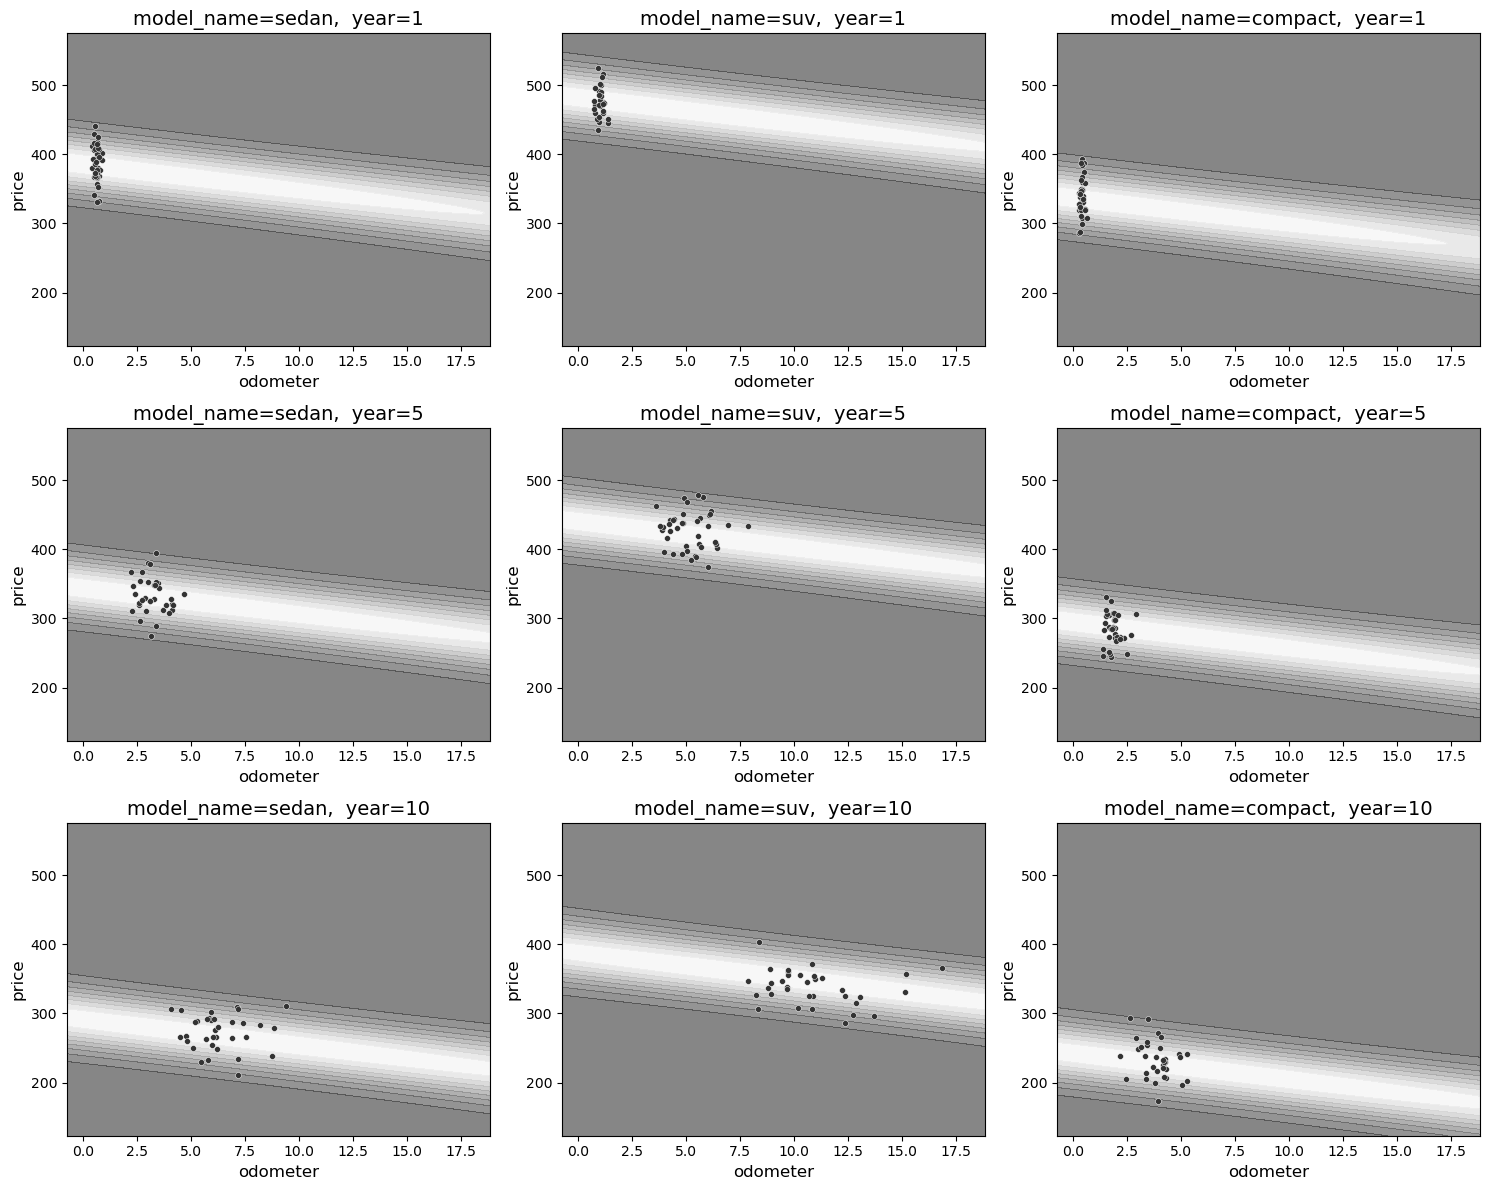

In [2]:
# 学習したリッジ回帰モデルの確率密度関数と学習データを重ねてプロット
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from scipy import stats

# 描画用のFigureとAxesを生成
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))
# 削除したカテゴリの列を表示用に追加する
droped_model_name = enc.categories_[0][0]
X_train_with_dropped = X_train.copy()
X_train_with_dropped[f'model_name_{droped_model_name}'] = (df_normal['model_name'] == droped_model_name).astype('float64')
# 車種ごとに図を分ける
for model_idx, model_cat_name in enumerate(model_cat_names + [f'model_name_{droped_model_name}']):
    X_train_model = X_train[X_train_with_dropped[model_cat_name] == 1]
    y_train_model = y_train[X_train_with_dropped[model_cat_name] == 1]
    # yearごとに図を分ける
    for year_idx, year in enumerate([1, 5, 10]):
        X_train_year = X_train_model[X_train_model['year'] == year]
        y_train_year = y_train_model[X_train_model['year'] == year]
        ###### 確率密度関数を描画 ######
        # (x,y)格子点を作成
        x_min, x_max = np.min(X_train['odometer']), np.max(X_train['odometer'])
        y_min, y_max = np.min(y_train), np.max(y_train)
        x_grid = np.linspace(x_min - 1, x_max + 2, num=100)
        y_grid = np.linspace(y_min - 50, y_max + 50, num=200)
        X, Y = np.meshgrid(x_grid, y_grid)
        XY_grid = np.c_[X.ravel(), Y.ravel()]
        # 格子点の説明変数データに車種とyearを追加
        X_all_grid = XY_grid[:, 0].reshape(-1, 1)
        for i_model in range(len(model_cat_names)):
            if i_model == model_idx:
                X_all_grid = np.insert(X_all_grid, i_model + 1, 1, axis=1)
            else:
                X_all_grid = np.insert(X_all_grid, i_model + 1, 0, axis=1)
        X_all_grid = np.insert(X_all_grid, 0, year, axis=1)  # year
        # 確率密度関数
        design_matrix_grid = np.concatenate(  # デザイン行列
            [np.ones((X_all_grid.shape[0], 1)), X_all_grid],
            axis=1)
        sx_all_grid = 1 + np.sum(design_matrix_grid @ A_inv * design_matrix_grid, axis=1)  # s(x)
        mu_all_grid = design_matrix_grid @ u  # 予測分布の平均
        var_all_grid = sigma2 * sx_all_grid  # 予測分布の分散
        pdf_all_grid = stats.norm.pdf(XY_grid[:, 1], loc=mu_all_grid, scale=np.sqrt(var_all_grid))
        # 確率密度をプロット
        pdf_grid_pivot = pdf_all_grid.reshape(X.shape)  # ピボット化
        axes[year_idx][model_idx].contourf(X, Y, pdf_grid_pivot, levels=10, cmap=cm.gray, alpha=0.5)

        ###### 学習データを散布図で描画 ######
        sns.scatterplot(x=X_train_year['odometer'], y=y_train_year,
                        c='#333333', ax=axes[year_idx][model_idx], s=18, marker="o")
        axes[year_idx][model_idx].set_xlabel('odometer', fontsize=12)
        axes[year_idx][model_idx].set_ylabel('price', fontsize=12)
        axes[year_idx][model_idx].set_title(f'{model_cat_name.replace("name_", "name=")},  year={year}', fontsize=14)
# グラフを表示
plt.tight_layout()
plt.show()

予測分布の形状は最尤推定（通常の多変数線形回帰）の場合と似ていますが、全体的に分散（分布の縦方向の幅）が⼤きくなっています。

通常の多変数線形回帰の場合と同様、学習後はone-hot encoding用のモデルをpickleなどで保存しておきます。

In [3]:
# pickleによるone-hot encoding 用モデルの保存
import pickle
filepath = './7_5_3_onehot_encoder.pkl' # モデルの保存ファイル名
with open(filepath,'wb') as p: #ファイルを開く
    pickle.dump(enc, p) # pickleでファイルにモデルを保存する

## C. 推論

学習フェーズで保存したモデル（リッジ回帰モデル＆one-hot encoding用モデル）としきい値を用いて、推論データに対する異常度の算出と異常判定を行います。

まず以下のように、学習時に保存したone-hot encoding用のモデルを`enc`変数に読み込んでおきます。

In [4]:
# pickleで保存したone-hot encoding 用モデルの読み込み
import pickle
filepath = './7_5_3_onehot_encoder.pkl' # モデルの保存ファイル名
with open(filepath,'rb') as p: #ファイルを開く
    enc = pickle.load(p) # pickle形式ファイルからモデルを読み込み

ここから以下の実装で、学習で求めたパラメータとしきい値を用いてリッジ回帰モデルによる異常判定を実施します。

In [5]:
# コード7.14 リッジ回帰による多説明変数の異常検知の実装例（推論）
###### 学習したパラメータをここに記載
# 線形予測子の切片＋係数パラメータ
U = [346.87914156, -10.45016303, -3.78305842, 48.86951706, 145.47489259]
# 残差の分散パラメータσ^2
SIGMA2=895.474696833559
A=[[1.00200000e+03, 5.53500000e+03, 3.73885700e+03, 3.38000000e+02, 3.26000000e+02],
   [5.53500000e+03, 3.90330000e+04, 2.64856485e+04, 1.83800000e+03, 1.83200000e+03],
   [3.73885700e+03, 2.64856485e+04, 2.17923882e+04, 1.13602862e+03, 1.91038335e+03],
   [3.38000000e+02, 1.83800000e+03, 1.13602862e+03, 3.38000000e+02, 2.00000000e+00],
   [3.26000000e+02, 1.83200000e+03, 1.91038335e+03, 2.00000000e+00, 3.26000000e+02]]
# 異常度のしきい値
A_TH=6.9724772675641615

###### 推論データの読み込みと前処理######
# CSVからPandas DataFrameにデータ読み込み
df_inference = pd.read_csv('./datasets/usedcar_dataset_inference.csv')
# カテゴリ変数'model_name'の数値化（one-hot encoding）
model_name_cat = enc.transform(df_inference[['model_name']].to_numpy()).toarray()
model_cat_names = [f'model_name_{col}' for col in enc.categories_[0][1:]]
df_model_name = pd.DataFrame(model_name_cat, columns=model_cat_names)
df_encoded = pd.concat([df_inference.drop('model_name', axis=1), df_model_name], axis=1)
# 学習データの説明変数（'year'）と応答変数（'price'）をNumpyのndarray化
X_inference = df_encoded[['year', 'odometer']+model_cat_names].to_numpy()
y_inference = df_encoded['price'].to_numpy()

###### 推論を実行######
# 異常度を算出
design_matrix = np.concatenate( # デザイン行列
    [np.ones((X_inference.shape[0], 1)), X_inference],
   axis=1)
A_inv = np.linalg.inv(np.array(A)) # Aの逆行列
sx = 1 + np.sum(design_matrix @ A_inv * design_matrix, axis=1) # s(x)
# 異常度の第一項
first_anom = np.log(2 * np.pi * SIGMA2 * sx) / 2
# 異常度の第二項
second_anom = ((y_inference - design_matrix @ U) ** 2) / (2 * SIGMA2 * sx)
anomaly_scores = first_anom + second_anom # 異常度を求める
# しきい値により異常の有無を判定
pred = np.where(anomaly_scores > A_TH, 'anomaly', 'normal')
# 推論結果を表示
print(pred)

['normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'norm

推論結果の決定境界（異常と正常の判定の境界）を可視化してみます。最尤推定のときと同様、個々のグラフは横軸に説明変数`year`、縦軸に応答変数`price`をとっており、横方向には車種（`model_name`）、縦方向には経過年数（`year`= 1, 5, 10）を変えたときのグラフを並べています。

/var/folders/9f/r2qdz_xx5cb0t0vdjxq090kh0000gn/T/ipykernel_25810/2929806905.py:53: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  sns.scatterplot(data=df_inference_year, x='odometer', y='price',
/var/folders/9f/r2qdz_xx5cb0t0vdjxq090kh0000gn/T/ipykernel_25810/2929806905.py:53: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  sns.scatterplot(data=df_inference_year, x='odometer', y='price',


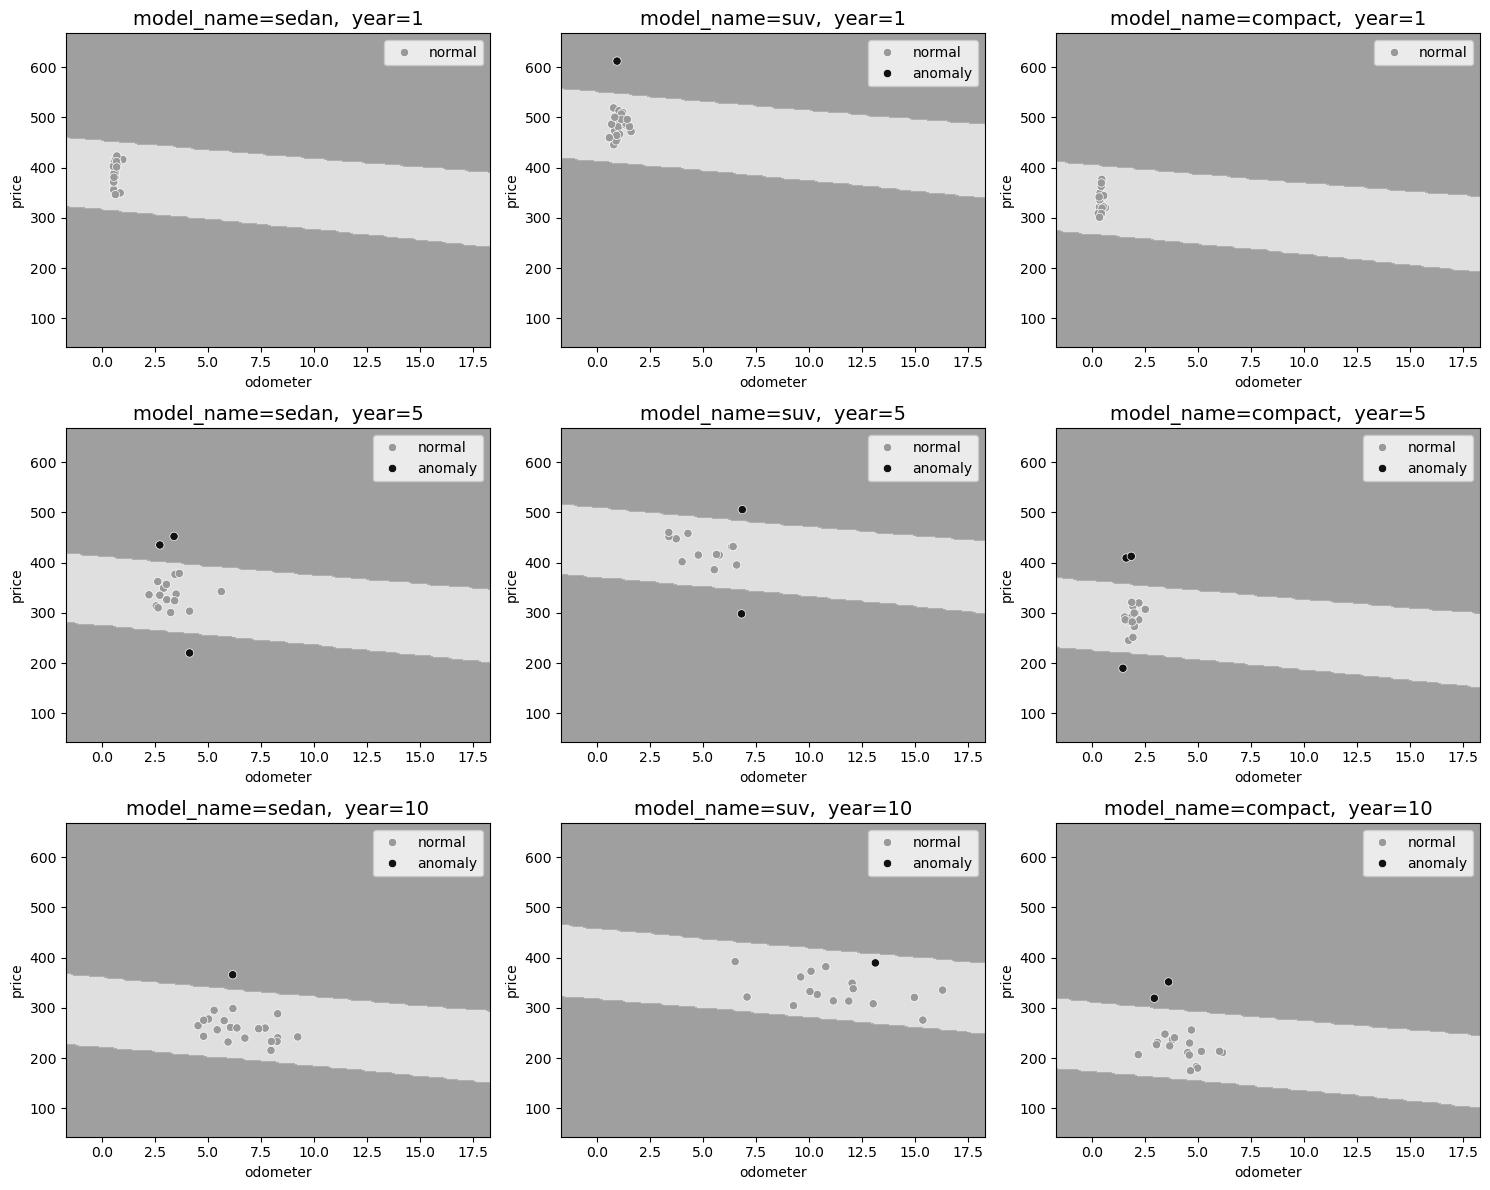

In [6]:
# 推論結果の決定境界を可視化
# 横軸と縦軸の拡張範囲（分散の変化を見たい場合は範囲を広げてください）
X_EXPANSION = 2
Y_EXPANSION = 50

# 描画用のFigureとAxesを生成
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))

###### 正常と異常の範囲を色分け ######
# 削除したカテゴリの列を表示用に追加する
droped_model_name = enc.categories_[0][0]
df_X_inference = df_encoded[['year', 'odometer'] + model_cat_names]
X_inference_with_dropped = df_X_inference.copy()
X_inference_with_dropped[f'model_name_{droped_model_name}'] = (df_inference['model_name'] == droped_model_name).astype('float64')
# 車種ごとに図を分ける
for model_idx, model_cat_name in enumerate(model_cat_names + [f'model_name_{droped_model_name}']):
    df_inference_model = df_inference[X_inference_with_dropped[model_cat_name] == 1]
    # yearごとに図を分ける
    for year_idx, year in enumerate([1, 5, 10]):
        df_inference_year = df_inference_model[df_inference_model['year'] == year]
        ###### 確率密度関数を描画 ######
        # (x,y)格子点を作成
        x_min, x_max = np.min(df_X_inference['odometer']), np.max(df_X_inference['odometer'])
        y_min, y_max = np.min(y_inference), np.max(y_inference)
        x_grid = np.linspace(x_min-X_EXPANSION, x_max+X_EXPANSION, num=100)
        y_grid = np.linspace(y_min-Y_EXPANSION, y_max+Y_EXPANSION, num=200)
        X, Y = np.meshgrid(x_grid, y_grid)
        XY_grid = np.c_[X.ravel(), Y.ravel()]
        # 格子点の説明変数データに車種とyearを追加
        X_all_grid = XY_grid[:, 0].reshape(-1, 1)
        for i_model in range(len(model_cat_names)):
            if i_model == model_idx:
                X_all_grid = np.insert(X_all_grid, i_model + 1, 1, axis=1)
            else:
                X_all_grid = np.insert(X_all_grid, i_model + 1, 0, axis=1)
        X_all_grid = np.insert(X_all_grid, 0, year, axis=1)  # year
        # 異常度を算出
        design_matrix_grid = np.concatenate(  # デザイン行列
            [np.ones((X_all_grid.shape[0], 1)), X_all_grid],
            axis=1)
        sx_grid = 1 + np.sum(design_matrix_grid @ A_inv * design_matrix_grid, axis=1)  # s(x)
        first_anom_grid = np.log(2 * np.pi * SIGMA2 * sx_grid) / 2  # 異常度の第1項
        second_anom_grid = ((XY_grid[:, 1] - design_matrix_grid @ U) ** 2) / (2 * SIGMA2 * sx_grid)  # 異常度の第2項
        anomaly_scores_grid = first_anom_grid + second_anom_grid  # 異常度を求める
        # しきい値判定
        pred_grid = np.where(anomaly_scores_grid > A_TH, 0, 1)
        # 正常と異常の境界をプロット
        pred_pivot = pred_grid.reshape(X.shape)
        axes[year_idx][model_idx].contourf(X, Y, pred_pivot, levels=1,
                            cmap=cm.gray, alpha=0.5)

        ###### 各データを散布図としてプロット ######
        sns.scatterplot(data=df_inference_year, x='odometer', y='price',
                        hue='label', palette=['#999999', '#111111'], ax=axes[year_idx][model_idx])
        # 図タイトルと凡例を追加
        axes[year_idx][model_idx].set_title(f'{model_cat_name.replace("name_", "name=")},  year={year}', fontsize=14)
        axes[year_idx][model_idx].legend()
# グラフを表示
plt.tight_layout()
plt.show()

最尤推定（通常の多変数線形回帰）とほぼ同じ決定境界が引かれていることがわかります。どちらの方法も、同じ学習データの異常度の分位点に基づきしきい値を決めているため、判定結果には予測分布ほどの差が出なかったと考えれられます。